In [184]:
import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt



In [185]:
# Function to add Gaussian noise
def add_noise(image, prob=0.7):  # 70% chance of applying noise
    if random.random() > prob:
        return image  # Skip noise
    
    row, col, ch = image.shape
    mean = 0
    var = random.uniform(5, 20)  # Randomized noise variance
    sigma = var ** 0.5
    gauss = np.random.normal(mean, sigma, (row, col, ch))
    noisy = image + gauss
    return np.clip(noisy, 0, 255).astype(np.uint8)

# Function to add shadows
def add_shadow(image, prob=0.5):  # 50% chance of applying shadow
    if random.random() > prob:
        return image  # Skip shadow
    
    h, w = image.shape[:2]
    shadow_mask = np.zeros_like(image, dtype=np.uint8)
    
    x1, y1 = np.random.randint(0, w//2), np.random.randint(0, h//2)
    x2, y2 = np.random.randint(w//2, w), np.random.randint(h//2, h)
    
    shadow_intensity = random.randint(30, 80)  # Random shadow darkness
    cv2.rectangle(shadow_mask, (x1, y1), (x2, y2), (shadow_intensity, shadow_intensity, shadow_intensity), -1)
    
    return cv2.addWeighted(image, 1, shadow_mask, 0.5, 0)

# Function to add notebook lines
def add_notebook_lines(image, prob=0.4):  # 40% chance of applying notebook lines
    if random.random() > prob:
        return image  # Skip notebook lines
    
    h, w = image.shape[:2]
    spacing = random.randint(30, 50)  # Randomized spacing
    
    for y in range(0, h, spacing):
        cv2.line(image, (0, y), (w, y), (0, 0, 0), 1)  # Light blue
    
    return image

def make_background_grey(image, prob=1.0):  # Always apply
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    mask = gray > 200  # Detect white regions
    
    # Generate random grey tone (light grey, not too dark)
    grey_value = random.randint(200, 240)  # Range for light grey
    
    # Change white regions to grey
    image[mask] = [grey_value, grey_value, grey_value]  # BGR for grey
    
    return image

# Function to apply all augmentations randomly
def augment_image(image):
    image = make_background_grey(image)
    image = add_noise(image, prob=0.7)         # 70% chance to apply noise
    image = add_shadow(image, prob=0.5)        # 50% chance to apply shadow
    image = add_notebook_lines(image, prob=0.4) # 40% chance to apply notebook lines
    return image


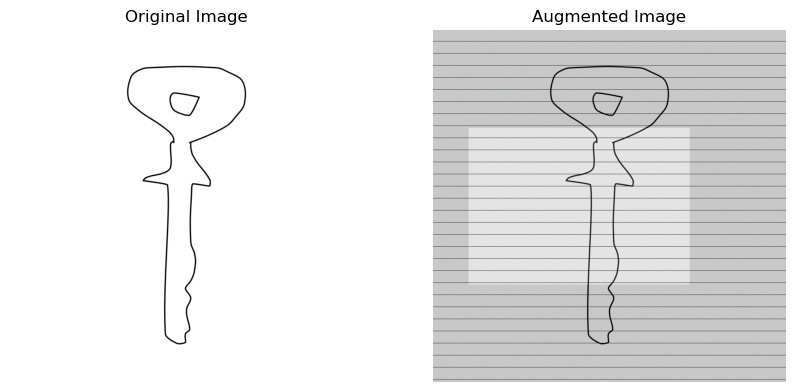

In [186]:
img_path = "png/key/9206.png"  # Replace with an actual image path

image = cv2.imread(img_path, cv2.IMREAD_COLOR)

# Make a copy to ensure the original is not modified
image_copy = image.copy()

# Apply augmentations
augmented_image = augment_image(image_copy)

# Display original and augmented images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Original should remain unchanged
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(augmented_image, cv2.COLOR_BGR2RGB))  # Augmented version
plt.title("Augmented Image")
plt.axis("off")

plt.show()


In [187]:
# import os
# import shutil
# import cv2
# import numpy as np

# # Directory paths
# source_dir = 'png'  # Original folder
# target_dir = 'png_modified'  # Folder where modified images will be saved

# # Create the target directory if it doesn't exist
# if not os.path.exists(target_dir):
#     os.makedirs(target_dir)

# # Ensure that the folder structure is replicated in the target directory
# for class_name in os.listdir(source_dir):
#     class_folder = os.path.join(source_dir, class_name)
#     if os.path.isdir(class_folder):
#         # Create corresponding class folder in the target directory
#         target_class_folder = os.path.join(target_dir, class_name)
#         if not os.path.exists(target_class_folder):
#             os.makedirs(target_class_folder)

#         # Process and save the augmented images
#         for img_name in os.listdir(class_folder):
#             img_path = os.path.join(class_folder, img_name)
#             if img_name.endswith('.png'):  # Check if it's a PNG image
#                 # Read image
#                 image = cv2.imread(img_path, cv2.IMREAD_COLOR)

#                 # Apply augmentations
#                 augmented_image = augment_image(image)

#                 # Save augmented image to target directory
#                 target_img_path = os.path.join(target_class_folder, img_name)
#                 cv2.imwrite(target_img_path, augmented_image)

# print("Augmentation complete. Images saved in 'png_modified'.")
